# ML Pipeline: Data Preparation, Hyperparameter Tuning, Evaluation & New Sample Prediction

This notebook performs:

1. Data preparation & custom padding for CSV samples.
2. Feature extraction by flattening two columns ("U(V)" and "j(mA)").
3. Dataset splitting & scaling.
4. Hyperparameter tuning via GridSearchCV for three models.
5. Evaluation of models & displaying predictions on the test set.
6. Prediction on a new sample.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

## 1. Determine the Maximum Row Count Among Samples

We scan all CSV files in the `csv_samples` folder to find the maximum row count.

In [ ]:
path_folder = './data/pb/'

In [ ]:
csv_folder = path_folder+'csv_samples'
csv_files = [os.path.join(csv_folder, f) for f in os.listdir(csv_folder) if f.endswith('.csv')]

max_length = 0
for file in csv_files:
    try:
        df = pd.read_csv(file)
        # Ensure required columns exist
        if not all(col in df.columns for col in ['U(V)', 'j(mA)']):
            continue
        num_rows = len(df)
        print(f"{file}: {num_rows} rows")
        if num_rows > max_length:
            max_length = num_rows
    except Exception as e:
        print(f"Error reading {file}: {e}")

print(f"Maximum number of rows among samples: {max_length}")

## 2. Build the Dataset with Custom Padding

For each sample, if its row count is less than max_length, we pad both columns:

- For each column, take its last value.
- Generate pad values by incrementing that value by 0.01 for each missing row.
- Concatenate these pad rows to the original data.

Then, flatten the two columns into a single feature vector and extract the label from the filename.


In [4]:
X_list = []
y_list = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue
    
    if not all(col in df.columns for col in ['U(V)', 'j(mA)']):
        print(f"Skipping {file}: Missing required columns.")
        continue

    current_length = len(df)
    padded_df = df[['U(V)', 'j(mA)']].copy()
    if current_length < max_length:
        pad_count = max_length - current_length
        # Get the last value for each column
        last_val_U = padded_df['U(V)'].iloc[-1]
        last_val_j = padded_df['j(mA)'].iloc[-1]
        # Create a new DataFrame with pad_count rows
        pad_df = pd.DataFrame({
            'U(V)': [last_val_U + 0.01 * (i + 1) for i in range(pad_count)],
            'j(mA)': [last_val_j + 0.01 * (i + 1) for i in range(pad_count)]
        })
        # Concatenate the original DataFrame with the pad DataFrame
        padded_df = pd.concat([padded_df, pad_df], ignore_index=True)
    
    if len(padded_df) != max_length:
        print(f"Error: Padded sample from {file} does not match required length.")
        continue
    
    # Flatten the two columns into a 1D feature vector.
    features = padded_df.to_numpy().flatten()
    X_list.append(features)
    
    # Extract the label from the filename (e.g., "Pb 48 L2.csv" -> 48)
    base_name = os.path.basename(file)
    match = re.search(r'Pb\s*([\d\.]+)', base_name)
    if match:
        label = float(match.group(1))
    else:
        print(f"Warning: No label found in filename {base_name}. Skipping file.")
        continue
    y_list.append(label)

# Convert lists to arrays.
try:
    X = np.vstack(X_list)
except Exception as e:
    raise ValueError(f"Error stacking feature vectors: {e}")
y = np.array(y_list)

print("Dataset shape (samples x features):", X.shape)
print("Labels shape:", y.shape)

Dataset shape (samples x features): (258, 244)
Labels shape: (258,)


## 3. Split the Dataset and Scale Features

We split the data (60% training, 40% testing) and standardize the features.

In [5]:
# Split the data with 60% for training and 40% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

# Standardize features to have zero mean and unit variance.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training samples: 154, Testing samples: 104


## 4. Hyperparameter Tuning with GridSearchCV for Three Models

We perform GridSearchCV (with 5‑fold CV) on:

- **Linear Regression:** tuning "fit_intercept".
- **Random Forest Regressor:** tuning "n_estimators" and "max_depth".
- **Gradient Boosting Regressor:** tuning "n_estimators", "learning_rate", and "max_depth".

Best parameters are printed and best models are saved with joblib.

In [7]:
# --- 1. Grid Search for Linear Regression ---
param_grid_lr = {
    "fit_intercept": [True, False]
}
grid_lr = GridSearchCV(LinearRegression(),
                         param_grid_lr,
                         cv=5,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)
print("Best parameters for Linear Regression:", grid_lr.best_params_)
# Save best Linear Regression estimator
# joblib.dump(grid_lr.best_estimator_, "best_linear_regression.pkl")


# --- 2. Grid Search for Random Forest Regressor ---
param_grid_rf = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [None, 10, 30, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [1,'sqrt', 'log2'],
    'bootstrap': [True, False],
    'criterion' :['friedman_mse'],
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                         param_grid_rf,
                         cv=5,
                         scoring='neg_mean_squared_error',
                         n_jobs=-7)
grid_rf.fit(X_train_scaled, y_train)
print("Best parameters for Random Forest:", grid_rf.best_params_)
# Save best Random Forest estimator
# joblib.dump(grid_rf.best_estimator_, "best_random_forest.pkl")


# --- 3. Grid Search for Gradient Boosting Regressor ---
param_grid_gb = {
    "n_estimators": [100, 200, 500, 1000],
    "learning_rate": [0.001, 0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10],
    "loss": ['squared_error', 'absolute_error'],
}
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42),
                         param_grid_gb,
                         cv=5,
                         scoring='neg_mean_squared_error',
                         n_jobs=-7)
grid_gb.fit(X_train_scaled, y_train)
print("Best parameters for Gradient Boosting:", grid_gb.best_params_)
# Save best Gradient Boosting estimator
# joblib.dump(grid_gb.best_estimator_, "best_gradient_boosting.pkl")


# ---4. Grid Search for XGBoost Regressor ---
# We set up a larger grid for XGBRegressor.
param_grid_xgb = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.001],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_reg = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
grid_xgb = RandomizedSearchCV(xgb_reg,
                              param_grid_xgb,
                              n_iter=50,
                              cv=5,
                              scoring='neg_mean_squared_error',
                              n_jobs=-7,
                              random_state=42)
grid_xgb.fit(X_train_scaled, y_train)
print("Best parameters for XGBoost:", grid_xgb.best_params_)
# Save best XGBoost estimator
# joblib.dump(grid_xgb.best_estimator_, "best_xgboost.pkl")

Best parameters for Linear Regression: {'fit_intercept': False}
Best parameters for Random Forest: {'bootstrap': False, 'criterion': 'friedman_mse', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best parameters for Gradient Boosting: {'learning_rate': 0.01, 'loss': 'squared_error', 'max_depth': 3, 'n_estimators': 1000}
Best parameters for XGBoost: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


## 5. Evaluate the Best Models on the Test Set

We predict on the test set and calculate the Mean Squared Error (MSE) for each model.

In [ ]:
# Predictions from the best models
y_pred_lr = grid_lr.best_estimator_.predict(X_test_scaled)
y_pred_rf = grid_rf.best_estimator_.predict(X_test_scaled)
y_pred_gb = grid_gb.best_estimator_.predict(X_test_scaled)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test_scaled)


def print_regression_metrics(true, pred, model_name="Model"):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    
    print(f"{model_name} Metrics:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R^2:  {r2:.4f}\n")
    return mse, rmse, mae, r2

metrics_lr = print_regression_metrics(y_test, y_pred_lr, "Linear Regression")
metrics_rf = print_regression_metrics(y_test, y_pred_rf, "Random Forest Regressor")
metrics_gb = print_regression_metrics(y_test, y_pred_gb, "Gradient Boosting Regressor")
metrics_xgb = print_regression_metrics(y_test, y_pred_xgb, "XGBoost")
 

Linear Regression Metrics:
  MSE:  165080.5297
  RMSE: 406.3010
  MAE:  65.5194
  R^2:  -743.1704

Random Forest Regressor Metrics:
  MSE:  2.6496
  RMSE: 1.6278
  MAE:  0.8284
  R^2:  0.9881

Gradient Boosting Regressor Metrics:
  MSE:  1.3106
  RMSE: 1.1448
  MAE:  0.5982
  R^2:  0.9941

XGBoost Metrics:
  MSE:  1.7612
  RMSE: 1.3271
  MAE:  0.7425
  R^2:  0.9921



## 6. Display Test Set Predictions

We display a table with the true labels and the predictions from each model on the test set.


In [ ]:
predictions_df = pd.DataFrame({
    "True Label": y_test,
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "XGBoost": y_pred_xgb,
})
print(predictions_df.head(10))

   True Label  Linear Regression  Random Forest  Gradient Boosting    XGBoost
0        0.75          14.125678       0.693554           0.695829   0.746429
1        0.40         -77.085887       0.649771           0.718718   0.799221
2        0.04          -1.563038       0.157567           0.220255   0.220658
3        0.85           0.641951       0.765184           0.852088   0.905447
4       24.00          -1.233062      24.500000          23.950865  23.981396
5       15.00          15.472192      15.175000          15.259437  15.110369
6       43.00          41.649880      40.100000          41.992175  41.459930
7        8.00          27.544496       8.067500           8.040857   7.946448
8       20.00          20.385289      20.370000          20.873759  21.436920
9       45.00          43.648492      43.410000          44.579738  44.606060


## 7. Predict on a New Sample

We load a new sample (from "new_sample.csv"), process it with the same padding (or truncation) logic,
scale it, and then predict its label using the three best models.

In [35]:
import random

In [ ]:
index = random.randint(0, len(y_test))
print ("ground truth: ", y_test[index])
new_sample_file = f"./data/pb/csv_samples/Pb {y_test[index]} L1.csv"
try:
    new_df = pd.read_csv(new_sample_file)
except Exception as e:
    print("Error reading new sample:", e)
    new_df = None

if new_df is not None:
    if not all(col in new_df.columns for col in ['U(V)', 'j(mA)']):
        print("New sample is missing required columns.")
    else:
        new_current_length = len(new_df)
        new_padded_df = new_df[['U(V)', 'j(mA)']].copy()
        # If the new sample has fewer rows, pad it; if more, truncate.
        if new_current_length < max_length:
            pad_count = max_length - new_current_length
            last_val_U = new_padded_df['U(V)'].iloc[-1]
            last_val_j = new_padded_df['j(mA)'].iloc[-1]
            pad_df_new = pd.DataFrame({
                'U(V)': [last_val_U + 0.01 * (i + 1) for i in range(pad_count)],
                'j(mA)': [last_val_j + 0.01 * (i + 1) for i in range(pad_count)]
            })
            new_padded_df = pd.concat([new_padded_df, pad_df_new], ignore_index=True)
        elif new_current_length > max_length:
            new_padded_df = new_padded_df.iloc[:max_length]
        
        if len(new_padded_df) != max_length:
            print("New sample processing error: final row count does not match required length.")
        else:
            # Flatten and reshape into (1, -1)
            new_features = new_padded_df.to_numpy().flatten().reshape(1, -1)
            # Scale using the previously fitted scaler
            new_features_scaled = scaler.transform(new_features)
            # Predict using the best models
            new_pred_lr = grid_lr.best_estimator_.predict(new_features_scaled)
            new_pred_rf = grid_rf.best_estimator_.predict(new_features_scaled)
            new_pred_gb = grid_gb.best_estimator_.predict(new_features_scaled)
            new_pre_xgb = grid_xgb.best_estimator_.predict(new_features_scaled)
            
            print("Predictions for new sample:")
            print("Linear Regression prediction:", new_pred_lr[0])
            print("Random Forest prediction:", new_pred_rf[0])
            print("Gradient Boosting prediction:", new_pred_gb[0])
            print("XGBoost prediction:", new_pre_xgb[0])

ground truth:  7.5
Predictions for new sample:
Linear Regression prediction: 7.513615803780112
Random Forest prediction: 7.50375
Gradient Boosting prediction: 7.382608427794643
XGBoost prediction: 7.413005


## 8. Visualize Model Performance

A bar plot shows the MSE for each model, with a horizontal line indicating the target MSE of 0.2.


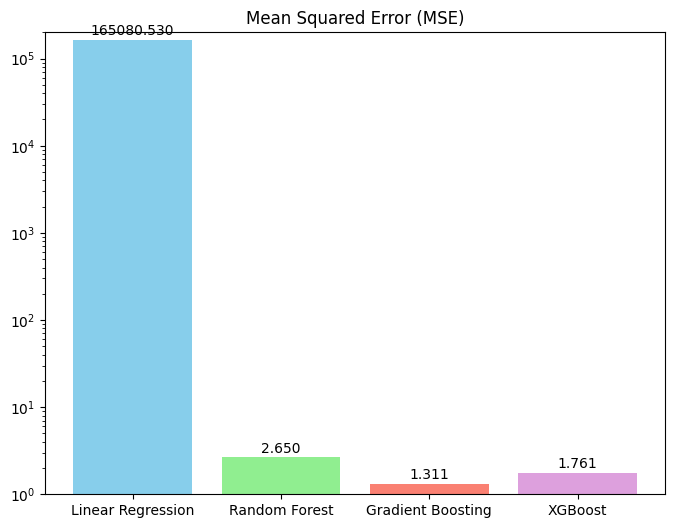

In [ ]:
models  = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']

# Prepare metric values for plotting; each list has 4 values.
mse_values  = [metrics_lr[0], metrics_rf[0], metrics_gb[0], metrics_xgb[0]]
rmse_values = [metrics_lr[1], metrics_rf[1], metrics_gb[1], metrics_xgb[1]]
mae_values  = [metrics_lr[2], metrics_rf[2], metrics_gb[2], metrics_xgb[2]]
r2_values   = [metrics_lr[3], metrics_rf[3], metrics_gb[3], metrics_xgb[3]]

plt.figure(figsize=(8, 6))
plt.bar(models, mse_values, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
plt.title("Mean Squared Error (MSE)")
plt.yscale('log')  # Use log scale to handle high differences
plt.ylim(1, 200000)  # Adjust these limits as needed
for i, v in enumerate(mse_values):
    plt.text(i, v*1.05, f"{v:.3f}", ha='center', va='bottom')
plt.show()

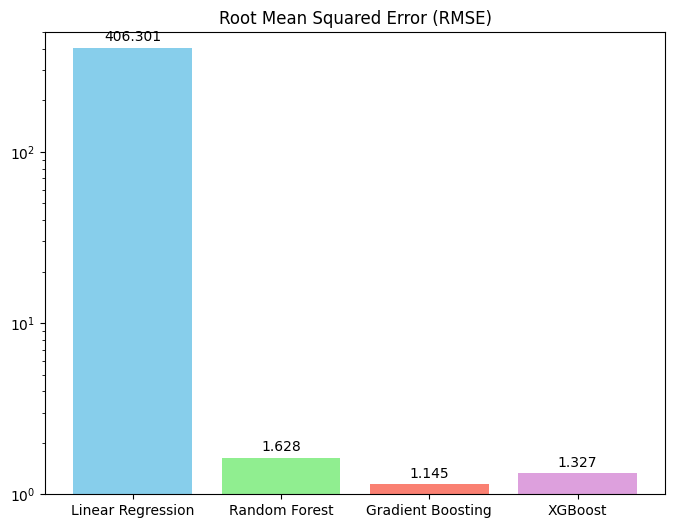

In [ ]:
plt.figure(figsize=(8, 6))
plt.bar(models, rmse_values, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
plt.title("Root Mean Squared Error (RMSE)")
plt.yscale('log')
plt.ylim(1, 500)  # Adjust these limits based on your data
for i, v in enumerate(rmse_values):
    plt.text(i, v*1.05, f"{v:.3f}", ha='center', va='bottom')
plt.show()

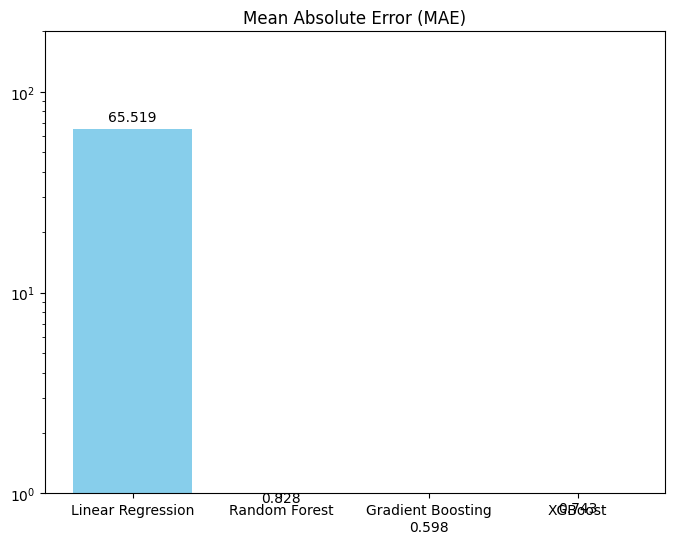

In [ ]:
plt.figure(figsize=(8, 6))
plt.bar(models, mae_values, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
plt.title("Mean Absolute Error (MAE)")
plt.yscale('log')
plt.ylim(1, 200)  # Adjust these limits as needed
for i, v in enumerate(mae_values):
    plt.text(i, v*1.05, f"{v:.3f}", ha='center', va='bottom')
plt.show()

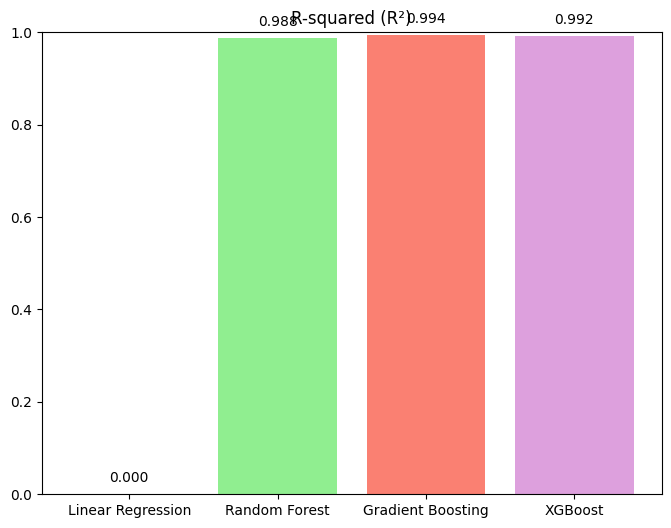

In [ ]:
r2_values_clipped = [np.clip(v, 0, 1) for v in r2_values]
plt.figure(figsize=(8, 6))
plt.bar(models, r2_values_clipped, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
plt.title("R-squared (R²)")
plt.ylim(0, 1)  # R^2 typically lies between 0 and 1
for i, v in enumerate(r2_values_clipped):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom')
plt.show()